In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

In [2]:
# ------------------------
# Physical and numerical parameters
# ------------------------
Lx = 1.0          # Length in x [m]
Ly = 1.0          # Length in y [m]
dx = 0.02         # Step in x [m]
dy = 0.02         # Step in y [m]
Nx = int(round(Lx/dx)) + 1
Ny = int(round(Ly/dy)) + 1
kappa = 2.3e-5    # Thermal diffusivity [m^2/s]
dt = 0.005        # Time step [s]
tol = 1e-4        # Convergence tolerance
Nmax = int(2e5)   # Max iterations

In [3]:
# ------------------------
# Stability parameters
# ------------------------
rx = kappa * dt / (2*dx**2)
ry = kappa * dt / (2*dy**2)

In [4]:
# ------------------------
# Grid and initial condition
# ------------------------
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

T = 30*np.ones((Ny, Nx))    # Initial temperature
T[:,0] = 0                  # Left BC
T[:,-1] = 100               # Right BC
T[0,:] = 0                  # Bottom BC
T[-1,:] = 100               # Top BC

T_init = T.copy()
T_mid = None
iter = 0
err = np.inf

Starting ADI iterations...
 Iteration        Max Error
---------------------------------
         1     6.034175e-02
       100     5.318377e-02
       200     4.698497e-02
       300     4.165649e-02
       400     3.706060e-02
       500     3.308335e-02
       600     2.963021e-02
       700     2.662247e-02
       800     2.399445e-02
       900     2.169112e-02
      1000     1.966627e-02
      1100     1.788097e-02
      1200     1.630235e-02
      1300     1.490255e-02
      1400     1.370434e-02
      1500     1.294462e-02
      1600     1.223579e-02
      1700     1.157457e-02
      1800     1.095778e-02
      1900     1.038235e-02
      2000     1.013563e-02
      2100     9.901773e-03
      2200     9.661683e-03
      2300     9.417929e-03
      2400     9.172632e-03
      2500     8.927532e-03
      2600     8.684049e-03
      2700     8.443327e-03
      2800     8.206284e-03
      2900     7.973641e-03
      3000     7.745956e-03
      3100     7.523655e-03
      3200     

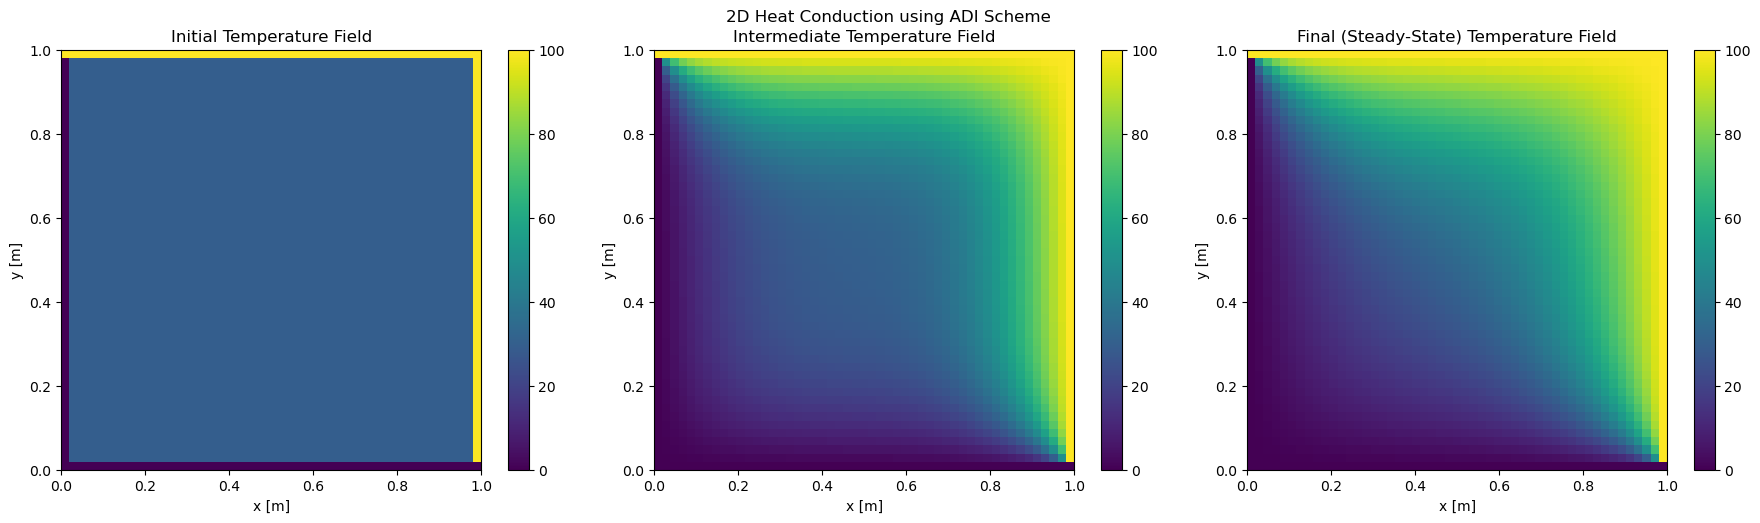

In [5]:
# ------------------------
# Precompute tridiagonal matrices for x and y
# ------------------------
# For solve_banded in SciPy, we need diagonals in a specific format: (upper, main, lower)
# X-direction matrix (Nx-2)
Ax_upper = -rx * np.ones(Nx-3)
Ax_main  = (1 + 2*rx) * np.ones(Nx-2)
Ax_lower = -rx * np.ones(Nx-3)
# Format for solve_banded: (upper_diag, main_diag, lower_diag)
Ax_banded = np.zeros((3, Nx-2))
Ax_banded[0,1:] = Ax_upper
Ax_banded[1,:] = Ax_main
Ax_banded[2,:-1] = Ax_lower

# Y-direction matrix (Ny-2)
Ay_upper = -ry * np.ones(Ny-3)
Ay_main  = (1 + 2*ry) * np.ones(Ny-2)
Ay_lower = -ry * np.ones(Ny-3)
Ay_banded = np.zeros((3, Ny-2))
Ay_banded[0,1:] = Ay_upper
Ay_banded[1,:] = Ay_main
Ay_banded[2,:-1] = Ay_lower

# ------------------------
# Iterative ADI loop
# ------------------------
print("Starting ADI iterations...")
print(f"{'Iteration':>10}  {'Max Error':>15}")
print('---------------------------------')

while iter < Nmax and err > tol:
    iter += 1
    Told = T.copy()

    # ---- Step 1: Implicit in x, explicit in y (n -> n+1/2) ----
    T_star = T.copy()
    for j in range(1, Ny-1):
        b = (1 - 2*rx)*T[j,1:-1] + \
            rx*(T[j,0:-2] + T[j,2:]) + \
            ry*(T[j-1,1:-1] - 2*T[j,1:-1] + T[j+1,1:-1])

        # Apply BCs in x
        b[0] += rx * T[j,0]
        b[-1] += rx * T[j,-1]

        # Solve tridiagonal system in x
        T_star[j,1:-1] = solve_banded((1,1), Ax_banded, b)

    # ---- Step 2: Implicit in y, explicit in x (n+1/2 -> n+1) ----
    for i in range(1, Nx-1):
        b = (1 - 2*ry)*T_star[1:-1,i] + \
            ry*(T_star[0:-2,i] + T_star[2:,i]) + \
            rx*(T_star[1:-1,i-1] - 2*T_star[1:-1,i] + T_star[1:-1,i+1])

        # Apply BCs in y
        b[0] += ry * T_star[0,i]
        b[-1] += ry * T_star[-1,i]

        # Solve tridiagonal system in y
        T[1:-1,i] = solve_banded((1,1), Ay_banded, b)

    # Reapply BCs
    T[:,0] = 0
    T[:,-1] = 100
    T[0,:] = 0
    T[-1,:] = 100

    # Error check
    err = np.max(np.abs(T - Told))

    # Print progress every 100 iterations
    if iter % 100 == 0 or iter == 1:
        print(f"{iter:10d}  {err:15.6e}")

    # Save middle snapshot
    if T_mid is None and iter > Nmax/2:
        T_mid = T.copy()

print('---------------------------------')
print(f"Steady state reached after {iter} iterations (error={err:.2e})")

# ------------------------
# Visualization
# ------------------------
fig, axes = plt.subplots(1,3,figsize=(18,5))

im0 = axes[0].imshow(T_init, origin='lower', extent=[0,Lx,0,Ly], aspect='equal', vmin=0, vmax=100)
axes[0].set_title('Initial Temperature Field')
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('y [m]')
plt.colorbar(im0, ax=axes[0])

if T_mid is not None:
    im1 = axes[1].imshow(T_mid, origin='lower', extent=[0,Lx,0,Ly], aspect='equal', vmin=0, vmax=100)
    axes[1].set_title('Intermediate Temperature Field')
    axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('y [m]')
    plt.colorbar(im1, ax=axes[1])
else:
    axes[1].axis('off')

im2 = axes[2].imshow(T, origin='lower', extent=[0,Lx,0,Ly], aspect='equal', vmin=0, vmax=100)
axes[2].set_title('Final (Steady-State) Temperature Field')
axes[2].set_xlabel('x [m]'); axes[2].set_ylabel('y [m]')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('2D Heat Conduction using ADI Scheme')
plt.tight_layout()
plt.show()
